In [1]:
import socket

ESP32_IP = "192.168.2.110"  # Change this to ESP32's IP
PORT = 12345  # Same as in ESP32 script

def move_to_esp32(pan, tilt):
    """Send move command to ESP32 via Wi-Fi and read the response."""
    command = f"MOVE:{pan},{tilt}\n"

    try:
        # Connect to ESP32
        esp_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        esp_socket.connect((ESP32_IP, PORT))
        esp_socket.sendall(command.encode())  # Send command

        # Wait for and print ESP32's response
        response = esp_socket.recv(1024).decode().strip()
        print("ESP32 Response:", response)

        esp_socket.close()
    except Exception as e:
        print("Connection error:", str(e))

# Example Usage
# move_to_esp32(30, -20)  # Moves PAN to 30°, TILT to -20°
# move_to_esp32(-45, 45)  # Moves PAN to -45°, TILT to 45°


In [74]:
move_to_esp32(0,0)

ESP32 Response: Moved to PAN=0, TILT=0


In [3]:
import time

In [4]:
move_to_esp32(10,9)
time.sleep(1)
move_to_esp32(9,10)

ESP32 Response: Moved to PAN=10, TILT=9
ESP32 Response: Moved to PAN=9, TILT=10


In [5]:
move_to_esp32(0,-32) # vertical min -64 else blocked

ESP32 Response: Moved to PAN=0, TILT=-32


In [78]:
# import seabreeze (use 'pyseabreeze')
import seabreeze.spectrometers as sb

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import time

# set graphics to be plotted in the notebook
%matplotlib inline 

devices = sb.list_devices()
print (devices)

[<SeaBreezeDevice STS:S03615>]


In [79]:
spec = sb.Spectrometer.from_serial_number("S03615")#STS-UV-L-100-400-SMA
# serial number
print (spec.serial_number)
# model
print (spec.model)
# number of pixels (as returned by seabreeze)
print (spec.pixels)
# set the integration time in microseconds
spec.integration_time_micros(400000)
time.sleep(2)

S03615
STS
1024


In [55]:
#set integration time
micro_time=.1*1e6 # us
spec.integration_time_micros(micro_time)
# load dark noise
dark_ = np.load(f'../../telescope/data/darkNoise/darkNoise_{micro_time/1e3}ms.npy')

In [56]:
move_to_esp32(0,0)

ESP32 Response: Moved to PAN=0, TILT=0


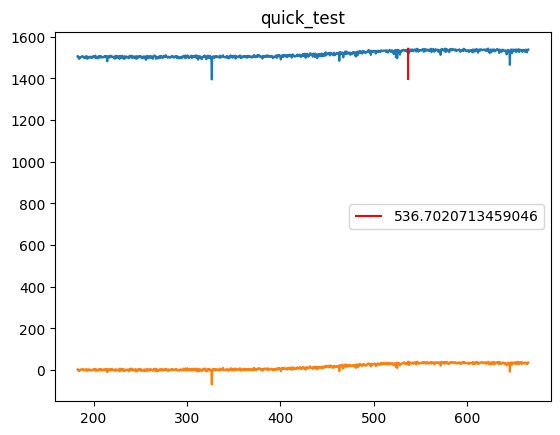

In [80]:
nm,ints = spec.spectrum()
plt.plot(nm,ints)
plt.plot(nm,ints-dark_)
plt.vlines(nm[np.argmax(ints)],np.min(ints),np.max(ints),color='r',label=nm[np.argmax(ints)])
plt.title('quick_test'.format(micro_time/1e3))
# plt.ylim(np.min(ints),np.max(ints))
plt.legend()

## use different integration time at a certain elevation
### this can be automized (e.g. take a quick vertical line scan, find the drop-> vertical line)

In [13]:
## quick test in Feb2025

In [68]:
h_left = 80
h_right = -80
stepsize_h = 2

h_steps = (np.abs(h_left)+np.abs(h_right))//stepsize_h

v_top = 40
v_threshold = -30
v_down = -40
stepsize_top=4
stepsize_down=4
v_steps = np.abs(v_top-v_threshold)//stepsize_top+np.abs(v_threshold-v_down)//stepsize_down


micro_time_top = 0.1 *1e6
micro_time_down = 1.0*1e6
top_dark_ = np.load(f'../../telescope/data/darkNoise/darkNoise_{micro_time_top/1e3}ms.npy')
down_dark_ = np.load(f'../../telescope/data/darkNoise/darkNoise_{micro_time_down/1e3}ms.npy')

In [69]:
output = np.zeros((v_steps+1,h_steps+1,1024))
print(output.shape)

(20, 81, 1024)


In [70]:
move_to_esp32(0,0)

ESP32 Response: Moved to PAN=0, TILT=0


In [71]:
import datetime
print(datetime.datetime.now())

2025-02-12 16:43:02.239526


In [ ]:
print('start at: ',datetime.datetime.now())
for hh,pan_ in enumerate(range(h_left,h_right,-stepsize_h)):
    for vv,tilt_ in enumerate(range(v_top,v_down,-stepsize_top)):
        move_to_esp32(pan_,tilt_)
        if tilt_>v_threshold:
            spec.integration_time_micros(micro_time_top)
        else:
            spec.integration_time_micros(micro_time_down)
        time.sleep(.5)
        _,output[vv,hh] = spec.spectrum()
print('finished at: ',datetime.datetime.now())

start at:  2025-02-12 17:04:29.584970
ESP32 Response: Moved to PAN=80, TILT=40
ESP32 Response: Moved to PAN=80, TILT=36
ESP32 Response: Moved to PAN=80, TILT=32
ESP32 Response: Moved to PAN=80, TILT=28
ESP32 Response: Moved to PAN=80, TILT=24
ESP32 Response: Moved to PAN=80, TILT=20
ESP32 Response: Moved to PAN=80, TILT=16
ESP32 Response: Moved to PAN=80, TILT=12
ESP32 Response: Moved to PAN=80, TILT=8
ESP32 Response: Moved to PAN=80, TILT=4
ESP32 Response: Moved to PAN=80, TILT=0
ESP32 Response: Moved to PAN=80, TILT=-4
ESP32 Response: Moved to PAN=80, TILT=-8
ESP32 Response: Moved to PAN=80, TILT=-12
ESP32 Response: Moved to PAN=80, TILT=-16
ESP32 Response: Moved to PAN=80, TILT=-20
ESP32 Response: Moved to PAN=80, TILT=-24
ESP32 Response: Moved to PAN=80, TILT=-28
ESP32 Response: Moved to PAN=80, TILT=-32
ESP32 Response: Moved to PAN=80, TILT=-36
ESP32 Response: Moved to PAN=78, TILT=40
ESP32 Response: Moved to PAN=78, TILT=36
ESP32 Response: Moved to PAN=78, TILT=32
ESP32 Response:

In [75]:
f_name = str(datetime.datetime.now())[:19].replace('-','_').replace(':','_').replace(' ','_')

In [76]:
np.save('./{}.npy'.format(f_name),output)

In [73]:
output.shape

(20, 81, 1024)